In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\Zakir Elaskar\credit-risk-system\credit-risk-system\data\raw\accepted_2007_to_2018Q4.csv.gz', 
                 compression='gzip',
                 low_memory=False, 
                 nrows=50000)

print("Shape:", df.shape)
print("Columns:", df.shape[1])
df.head(3)

Shape: (50000, 151)
Columns: 151


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print(df.columns.tolist())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

## Here's the business logic:
Default (1) — bad loans:

Charged Off — bank wrote it off as a loss. This is a default.
Default — explicitly defaulted.
Late (31-120 days) — seriously late, likely heading to default.

Good (0) — good loans:

Fully Paid — paid completely. Clearly good.

Remove entirely — ambiguous:

Current — loan is still active, we don't know outcome yet
Late (16-30 days) — early stage, could recover
In Grace Period — too early to call

In [4]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid            34978
Charged Off            9027
Current                5610
Late (31-120 days)      246
In Grace Period         100
Late (16-30 days)        38
Default                   1
Name: count, dtype: int64


In [5]:
# Step 1 — Keep only conclusive loans
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default', 'Late (31-120 days)'])]

# Step 2 — Create binary target variable
# 1 = default, 0 = good loan
df['target'] = df['loan_status'].apply(lambda x: 0 if x == 'Fully Paid' else 1)

# Step 3 — Check the result
print("Total loans:", len(df))
print("\nTarget distribution:")
print(df['target'].value_counts())
print("\nDefault rate:", round(df['target'].mean() * 100, 2), "%")

Total loans: 44252

Target distribution:
target
0    34978
1     9274
Name: count, dtype: int64

Default rate: 20.96 %


## Target Variable Analysis

Loan status collapsed into binary target:
- 0 = Fully Paid (good loan)
- 1 = Charged Off / Default / Late 31-120 days (bad loan)

Removed ambiguous statuses: Current, In Grace Period, Late 16-30 days
These represent loans with unknown outcomes that would introduce noise.

**Default rate: 20.96%**
This significant class imbalance (79/21 split) means we cannot use 
accuracy as our evaluation metric. A model predicting "good loan" 
for everyone would achieve 79% accuracy while catching zero defaults.
We will address this using SMOTE and class_weight parameters during modeling.

In [6]:
# Check missing values across all columns 
missing = df.isnull().sum()
missing_pct =(df.isnull().sum() / len(df)) *100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': round(missing_pct, 2)
})

# Only show columns that actually have missing values
missing_df = missing_df[missing_df['missing_count'] > 0]
missing_df = missing_df.sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(missing_df)}")
print(missing_df.head(20))

Columns with missing values: 72
                                            missing_count  missing_pct
member_id                                           44252       100.00
sec_app_chargeoff_within_12_mths                    44252       100.00
sec_app_collections_12_mths_ex_med                  44252       100.00
sec_app_mths_since_last_major_derog                 44252       100.00
sec_app_mort_acc                                    44252       100.00
sec_app_open_acc                                    44252       100.00
sec_app_revol_util                                  44252       100.00
revol_bal_joint                                     44252       100.00
sec_app_open_act_il                                 44252       100.00
sec_app_earliest_cr_line                            44252       100.00
sec_app_fico_range_high                             44252       100.00
sec_app_fico_range_low                              44252       100.00
sec_app_inq_last_6mths                       

In [7]:
# Drop columns with more than 50% missing values
threshold = 50
cols_to_drop = missing_df[missing_df['missing_pct'] > threshold].index.tolist()

print(f"Dropping {len(cols_to_drop)} columns with >50% missing values")
print(cols_to_drop)

df = df.drop(columns=cols_to_drop)
print(f"\nRemaining columns: {df.shape[1]}")

Dropping 57 columns with >50% missing values
['member_id', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'revol_bal_joint', 'sec_app_open_act_il', 'sec_app_earliest_cr_line', 'sec_app_fico_range_high', 'sec_app_fico_range_low', 'sec_app_inq_last_6mths', 'sec_app_num_rev_accts', 'desc', 'dti_joint', 'annual_inc_joint', 'verification_status_joint', 'orig_projected_additional_accrued_interest', 'next_pymnt_d', 'hardship_reason', 'hardship_end_date', 'hardship_type', 'hardship_status', 'hardship_loan_status', 'hardship_dpd', 'hardship_length', 'payment_plan_start_date', 'hardship_start_date', 'deferral_term', 'hardship_last_payment_amount', 'hardship_payoff_balance_amount', 'hardship_amount', 'settlement_amount', 'settlement_date', 'settlement_status', 'settlement_term', 'debt_settlement_flag_date', 'settlement_percentage', 'mths_since_last_record', 'mths_since_r

## Data Leakage Removal

Columns like total_pymnt, recoveries, and out_prncp only exist after 
the loan lifecycle is complete. At the time of application these values 
are unknown — the borrower hasn't made any payments yet.

Using these columns would give the model information it cannot possibly 
have in production, resulting in artificially high accuracy that 
completely fails on real applicants.

This is called data leakage and it is one of the most common and 
dangerous mistakes in credit risk modeling.

In [8]:
# Remove data leakage columns
# These only exist AFTER loan outcome is known
# In production, we won't have this info at application time
leakage_cols = [
    'out_prncp', 'out_prncp_inv',        # outstanding principal after payments
    'total_pymnt', 'total_pymnt_inv',     # total amount paid
    'total_rec_prncp', 'total_rec_int',   # amount recovered
    'total_rec_late_fee',                 # late fees collected
    'recoveries', 'collection_recovery_fee', # post-default recovery
    'last_pymnt_d', 'last_pymnt_amnt',    # last payment info
    'last_credit_pull_d',                 # last time credit was checked
]

# Only drop columns that exist in our dataframe
leakage_cols = [col for col in leakage_cols if col in df.columns]

df = df.drop(columns=leakage_cols)
print(f"Removed {len(leakage_cols)} leakage columns")
print(f"Remaining columns: {df.shape[1]}")

Removed 12 leakage columns
Remaining columns: 83


In [9]:
# Remove identifier and irrelevant columns
# These have no predictive value for default risk
useless_cols = [
    'id',           # unique loan identifier
    'url',          # link to listing page
    'title',        # free text loan title, too noisy
    'zip_code',     # too granular, too many unique values

    'pymnt_plan',   # almost always 'n', no variance
    'policy_code',  # always 1, no variance
    'application_type', # mostly individual
]

# Only drop if exists
useless_cols = [col for col in useless_cols if col in df.columns]

df = df.drop(columns=useless_cols)
print(f"Removed {len(useless_cols)} useless columns")
print(f"Remaining columns: {df.shape[1]}")
print(f"\nRemaining column names:")
print(df.columns.tolist())

Removed 7 useless columns
Remaining columns: 76

Remaining column names:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sat

In [10]:
print('addr_state' in df.columns )

True


In [11]:
# Keeping addr_state — regional economic conditions affect default risk
# Unemployment rates, cost of living, and housing market stability
# vary significantly by state. A $50,000 income means very different 
# things in Mississippi vs California.
# Regional risk patterns are a documented factor in real credit scoring.

In [12]:
# Basic statistics of key numerical columns
key_cols = ['loan_amnt', 'annual_inc', 'dti', 'int_rate', 
            'fico_range_low', 'revol_util', 'installment']

df[key_cols].describe().round(2)

,loan_amnt,annual_inc,dti,int_rate,fico_range_low,revol_util,installment
count,44252.00,44252.00,44251.00,44252.00,44252.00,44229.00,44252.00
mean,14351.67,78499.83,19.09,12.01,694.30,51.33,429.20
std,8624.56,102198.03,9.91,4.19,31.15,24.17,254.71
min,1000.00,0.00,0.00,5.32,660.00,0.00,14.77
25%,7800.00,47000.00,12.43,9.17,670.00,33.20,244.25
50%,12000.00,65000.00,18.54,11.49,685.00,51.00,369.57
75%,20000.00,94000.00,25.32,14.48,710.00,69.70,572.19
max,35000.00,9000000.00,999.00,28.99,845.00,145.80,1354.66


## LendingClub borrower profile —
LendingClub borrowers are not wealthy people making strategic financial moves. They are typically middle income people already carrying significant debt who need additional credit — often for debt consolidation, medical bills, or emergency expenses.
This matters because it means the platform attracts inherently higher risk borrowers than a traditional bank. Which explains the 20.96% default rate we found yesterday — far above the 2-3% typical bank default rate.

In [13]:
# Fix 1 — Cap annual income at 99th percentile
income_cap = df['annual_inc'].quantile(0.99)
print(f"Income cap (99th percentile): ${income_cap:,.0f}")
df['annual_inc'] = df['annual_inc'].clip(upper=income_cap)

# Fix 2 — Fix impossible DTI values
print(f"DTI values above 100 before fix: {(df['dti'] > 100).sum()}")
df['dti'] = df['dti'].where(df['dti'] <= 100, other=None)

# Fix 3 — Fix impossible revol_util values  
print(f"Revol util above 100 before fix: {(df['revol_util'] > 100).sum()}")
df['revol_util'] = df['revol_util'].where(df['revol_util'] <= 100, other=None)

print("\nAfter fixes:")
print(df[['annual_inc', 'dti', 'revol_util']].describe().round(2))

Income cap (99th percentile): $265,000
DTI values above 100 before fix: 3
Revol util above 100 before fix: 225

After fixes:
       annual_inc       dti  revol_util
count    44252.00  44248.00    44004.00
mean     76064.15     19.07       51.07
std      43426.40      8.72       23.95
min          0.00      0.00        0.00
25%      47000.00     12.43       33.10
50%      65000.00     18.54       50.80
75%      94000.00     25.32       69.40
max     265000.00     90.00      100.00


In [14]:
print("Zero Income Borrower: ", (df['annual_inc']== 0).sum())
print("Percentage: ", round((df['annual_inc'] == 0).mean() * 100, 4), "%")

Zero Income Borrower:  1
Percentage:  0.0023 %


In [15]:
print(df.shape)
print('grade' in df.columns)
print('annual_inc' in df.columns)
print('fico_range_low'  in df.columns)
print('fico_range_high' in df.columns)

(44252, 76)
True
True
True
True


In [16]:
grade_default = df.groupby('grade')['target'].mean().reset_index()
grade_default.columns = ['grade', 'default_rate']
print(grade_default)

  grade  default_rate
0     A      0.053788
1     B      0.140653
2     C      0.240478
3     D      0.357654
4     E      0.457163
5     F      0.537190
6     G      0.569948


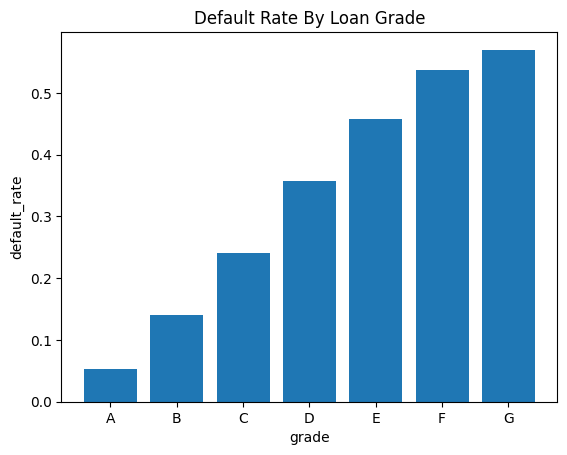

In [17]:
plt.bar(grade_default['grade'] ,grade_default['default_rate']) 
plt.title("Default Rate By Loan Grade")
plt.xlabel("grade")
plt.ylabel("default_rate")
plt.show()

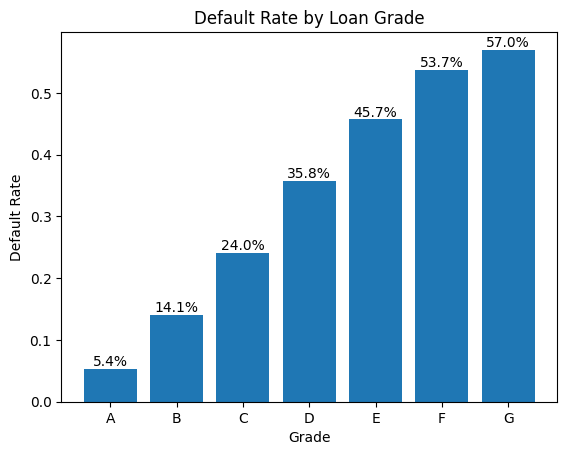

In [18]:
bars = plt.bar(grade_default['grade'], grade_default['default_rate'])

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,  
        bar.get_height() + 0.005,            
        f"{bar.get_height() * 100:.1f}%",                                  
        ha='center'
    )

plt.title('Default Rate by Loan Grade')
plt.xlabel('Grade')
plt.ylabel('Default Rate')
plt.show()

In [20]:
df['fico_mid'] = (df['fico_range_low'] + df['fico_range_high'])/2
df['fico_mid'].describe()

count    44252.000000
mean       696.295715
std         31.152960
min        662.000000
25%        672.000000
50%        687.000000
75%        712.000000
max        847.500000
Name: fico_mid, dtype: float64

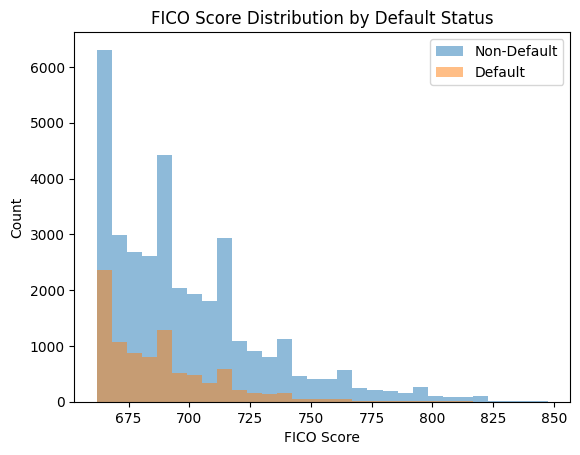

In [21]:
plt.hist(df[df['target'] == 0]['fico_mid'], bins=30, alpha=0.5, label='Non-Default')
plt.hist(df[df['target'] == 1]['fico_mid'], bins=30, alpha=0.5, label='Default')
plt.title('FICO Score Distribution by Default Status')
plt.xlabel('FICO Score')
plt.ylabel('Count')
plt.legend()
plt.show()

In [ ]:
 distribution of annual_inc